In [1]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt 
import seaborn as sns 
from sklearn.model_selection import train_test_split 
from sklearn.linear_model import LogisticRegression 
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier 
from sklearn.svm import SVC 
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score,f1_score,recall_score,classification_report
from xgboost import XGBClassifier
from sklearn.ensemble import GradientBoostingClassifier
import warnings 
warnings.filterwarnings('ignore')


In [2]:
data=pd.read_csv('Breast_Cancer.csv')

In [3]:
data

,Age,Race,Marital Status,T Stage,N Stage,6th Stage,differentiate,Grade,A Stage,Tumor Size,Estrogen Status,Progesterone Status,Regional Node Examined,Reginol Node Positive,Survival Months,Status
0,68,White,Married,T1,N1,IIA,Poorly differentiated,3,Regional,4,Positive,Positive,24,1,60,Alive
1,50,White,Married,T2,N2,IIIA,Moderately differentiated,2,Regional,35,Positive,Positive,14,5,62,Alive
2,58,White,Divorced,T3,N3,IIIC,Moderately differentiated,2,Regional,63,Positive,Positive,14,7,75,Alive
3,58,White,Married,T1,N1,IIA,Poorly differentiated,3,Regional,18,Positive,Positive,2,1,84,Alive
4,47,White,Married,T2,N1,IIB,Poorly differentiated,3,Regional,41,Positive,Positive,3,1,50,Alive
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4019,62,Other,Married,T1,N1,IIA,Moderately differentiated,2,Regional,9,Positive,Positive,1,1,49,Alive
4020,56,White,Divorced,T2,N2,IIIA,Moderately differentiated,2,Regional,46,Positive,Positive,14,8,69,Alive
4021,68,White,Married,T2,N1,IIB,Moderately differentiated,2,Regional,22,Positive,Negative,11,3,69,Alive
4022,58,Black,Divorced,T2,N1,IIB,Moderately differentiated,2,Regional,44,Positive,Positive,11,1,72,Alive


In [4]:
data['Status'].value_counts()

Status
Alive    3408
Dead      616
Name: count, dtype: int64

## EDA

In [5]:
data.columns

Index(['Age', 'Race', 'Marital Status', 'T Stage ', 'N Stage', '6th Stage',
       'differentiate', 'Grade', 'A Stage', 'Tumor Size', 'Estrogen Status',
       'Progesterone Status', 'Regional Node Examined',
       'Reginol Node Positive', 'Survival Months', 'Status'],
      dtype='object')

In [6]:
data.columns=data.columns.str.strip().str.lower().str.replace(' ','_',regex=True)

In [7]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4024 entries, 0 to 4023
Data columns (total 16 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   age                     4024 non-null   int64 
 1   race                    4024 non-null   object
 2   marital_status          4024 non-null   object
 3   t_stage                 4024 non-null   object
 4   n_stage                 4024 non-null   object
 5   6th_stage               4024 non-null   object
 6   differentiate           4024 non-null   object
 7   grade                   4024 non-null   object
 8   a_stage                 4024 non-null   object
 9   tumor_size              4024 non-null   int64 
 10  estrogen_status         4024 non-null   object
 11  progesterone_status     4024 non-null   object
 12  regional_node_examined  4024 non-null   int64 
 13  reginol_node_positive   4024 non-null   int64 
 14  survival_months         4024 non-null   int64 
 15  stat

In [8]:
data.describe()

,age,tumor_size,regional_node_examined,reginol_node_positive,survival_months
count,4024.000000,4024.000000,4024.000000,4024.000000,4024.000000
mean,53.972167,30.473658,14.357107,4.158052,71.297962
std,8.963134,21.119696,8.099675,5.109331,22.921430
min,30.000000,1.000000,1.000000,1.000000,1.000000
25%,47.000000,16.000000,9.000000,1.000000,56.000000
50%,54.000000,25.000000,14.000000,2.000000,73.000000
75%,61.000000,38.000000,19.000000,5.000000,90.000000
max,69.000000,140.000000,61.000000,46.000000,107.000000


In [9]:
data.shape

(4024, 16)

In [10]:
data.isna().sum()

age                       0
race                      0
marital_status            0
t_stage                   0
n_stage                   0
6th_stage                 0
differentiate             0
grade                     0
a_stage                   0
tumor_size                0
estrogen_status           0
progesterone_status       0
regional_node_examined    0
reginol_node_positive     0
survival_months           0
status                    0
dtype: int64

In [11]:
data.duplicated().sum()

np.int64(1)

In [12]:
data.drop_duplicates(inplace=True)

In [13]:
data.duplicated().sum()

np.int64(0)

In [14]:
cat_cols=data.select_dtypes(include='O').columns

In [15]:
for col in cat_cols:
    print(col)
    print(data[col].nunique())
    print(data[col].unique())
    print('\n','-'*100,'\n')

race
3
['White' 'Black' 'Other']

 ---------------------------------------------------------------------------------------------------- 

marital_status
5
['Married' 'Divorced' 'Single ' 'Widowed' 'Separated']

 ---------------------------------------------------------------------------------------------------- 

t_stage
4
['T1' 'T2' 'T3' 'T4']

 ---------------------------------------------------------------------------------------------------- 

n_stage
3
['N1' 'N2' 'N3']

 ---------------------------------------------------------------------------------------------------- 

6th_stage
5
['IIA' 'IIIA' 'IIIC' 'IIB' 'IIIB']

 ---------------------------------------------------------------------------------------------------- 

differentiate
4
['Poorly differentiated' 'Moderately differentiated' 'Well differentiated'
 'Undifferentiated']

 ---------------------------------------------------------------------------------------------------- 

grade
4
['3' '2' '1' ' anaplastic; Grade IV']



In [16]:
num_cols=data.select_dtypes(include='number').columns

In [17]:
num_cols

Index(['age', 'tumor_size', 'regional_node_examined', 'reginol_node_positive',
       'survival_months'],
      dtype='object')

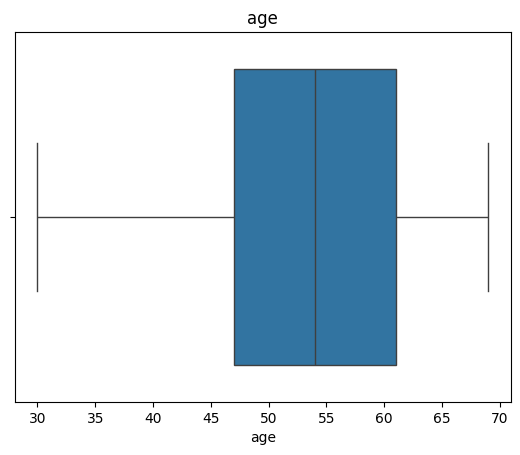

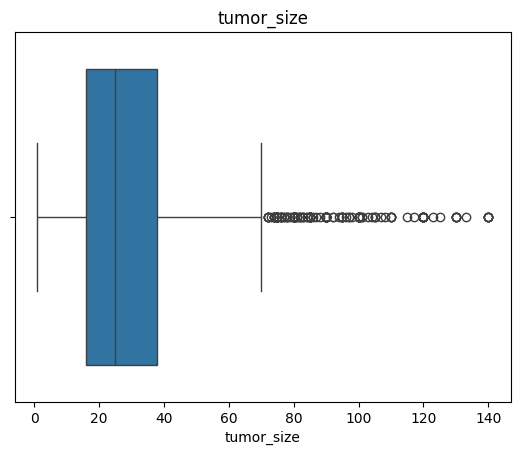

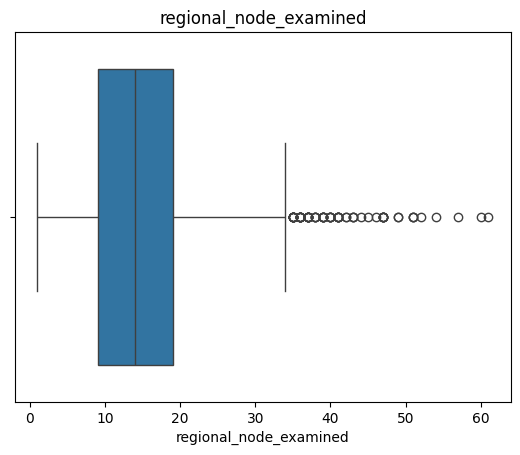

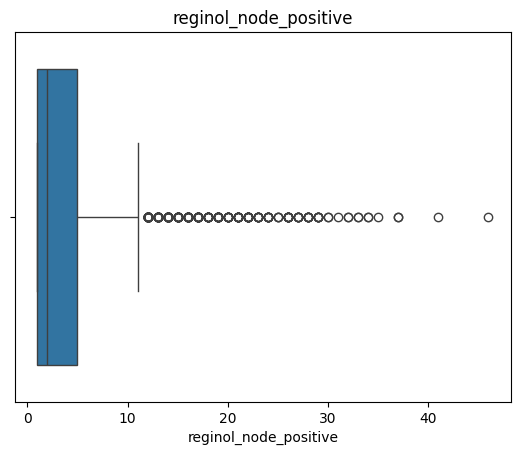

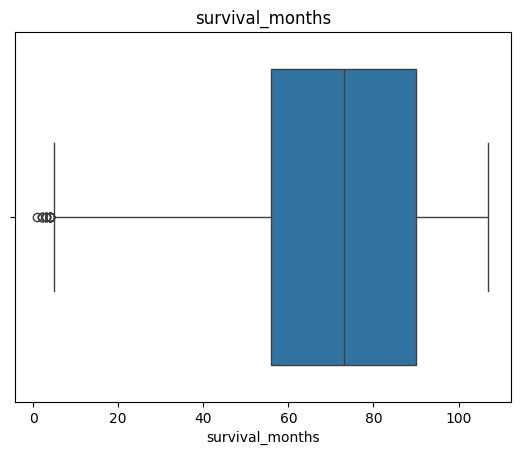

In [18]:
# for col in num_cols:
#     plt.figure()
#     sns.boxplot(data=data, x=col)
#     plt.title(col)
#     plt.show()
for col in num_cols:
    plt.figure()
    sns.boxplot(data=data,x=col)
    plt.title(col)
    plt.show()

In [19]:
num_cols

Index(['age', 'tumor_size', 'regional_node_examined', 'reginol_node_positive',
       'survival_months'],
      dtype='object')

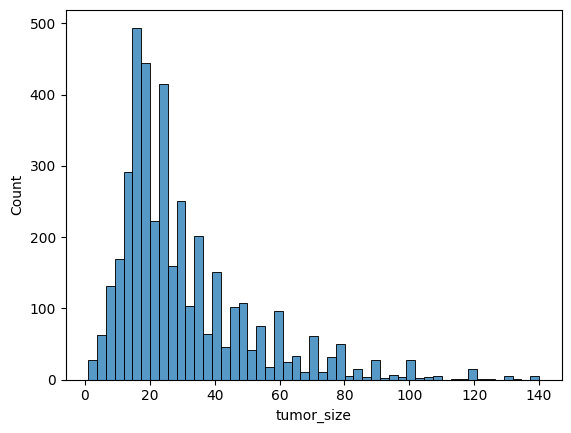

In [20]:
sns.histplot(data['tumor_size'])
plt.show()

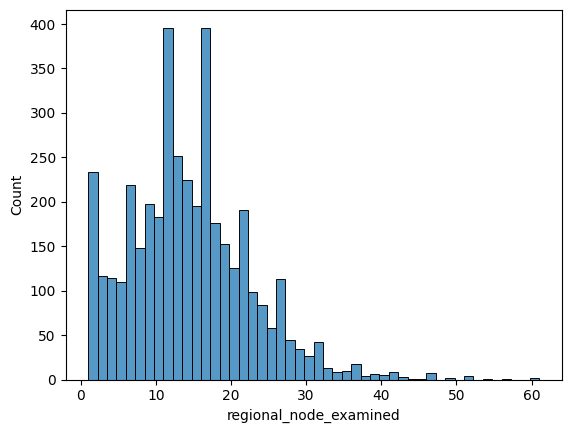

In [21]:
sns.histplot(data['regional_node_examined'])
plt.show()

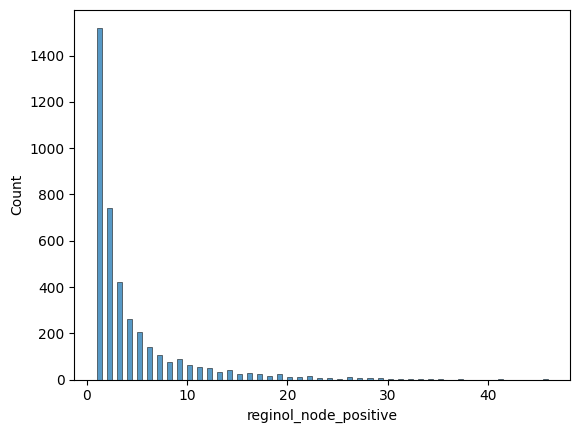

In [22]:
sns.histplot(data['reginol_node_positive'])
plt.show()

## ِAnalysis

In [23]:
data['status'].value_counts()

status
Alive    3407
Dead      616
Name: count, dtype: int64

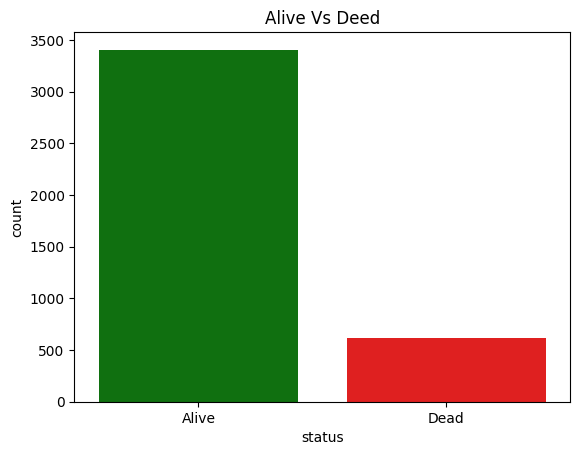

In [24]:
sns.countplot(x='status',data=data,palette=['green','red'])
plt.title('Alive Vs Deed')
plt.show()

## Spilting

In [25]:
from sklearn.preprocessing import LabelEncoder
le=LabelEncoder()
data['status']=le.fit_transform(data['status'])

In [26]:
data

,age,race,marital_status,t_stage,n_stage,6th_stage,differentiate,grade,a_stage,tumor_size,estrogen_status,progesterone_status,regional_node_examined,reginol_node_positive,survival_months,status
0,68,White,Married,T1,N1,IIA,Poorly differentiated,3,Regional,4,Positive,Positive,24,1,60,0
1,50,White,Married,T2,N2,IIIA,Moderately differentiated,2,Regional,35,Positive,Positive,14,5,62,0
2,58,White,Divorced,T3,N3,IIIC,Moderately differentiated,2,Regional,63,Positive,Positive,14,7,75,0
3,58,White,Married,T1,N1,IIA,Poorly differentiated,3,Regional,18,Positive,Positive,2,1,84,0
4,47,White,Married,T2,N1,IIB,Poorly differentiated,3,Regional,41,Positive,Positive,3,1,50,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4019,62,Other,Married,T1,N1,IIA,Moderately differentiated,2,Regional,9,Positive,Positive,1,1,49,0
4020,56,White,Divorced,T2,N2,IIIA,Moderately differentiated,2,Regional,46,Positive,Positive,14,8,69,0
4021,68,White,Married,T2,N1,IIB,Moderately differentiated,2,Regional,22,Positive,Negative,11,3,69,0
4022,58,Black,Divorced,T2,N1,IIB,Moderately differentiated,2,Regional,44,Positive,Positive,11,1,72,0


In [27]:
x= data.drop('status', axis=1)
y= data['status']

In [28]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42,stratify=y)

In [29]:
num_cols

Index(['age', 'tumor_size', 'regional_node_examined', 'reginol_node_positive',
       'survival_months'],
      dtype='object')

## preprocessing 

In [30]:
x_train['tumor_size']=np.log1p(x_train['tumor_size'])
x_test['tumor_size']=np.log1p(x_test['tumor_size'])

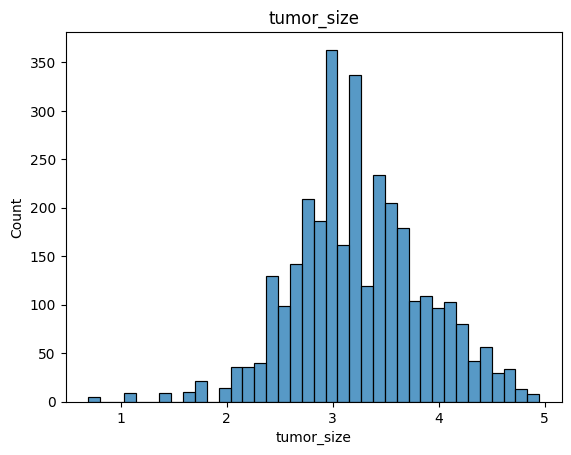

In [31]:
sns.histplot(x_train['tumor_size'])
plt.title('tumor_size')
plt.show()

In [32]:
from sklearn.preprocessing import StandardScaler

# إنشاء StandardScaler
scaler = StandardScaler()

# تطبيق StandardScaler على البيانات
x_train[['tumor_size']] = scaler.fit_transform(x_train[['tumor_size']])
x_test[['tumor_size']] = scaler.transform(x_test[['tumor_size']])


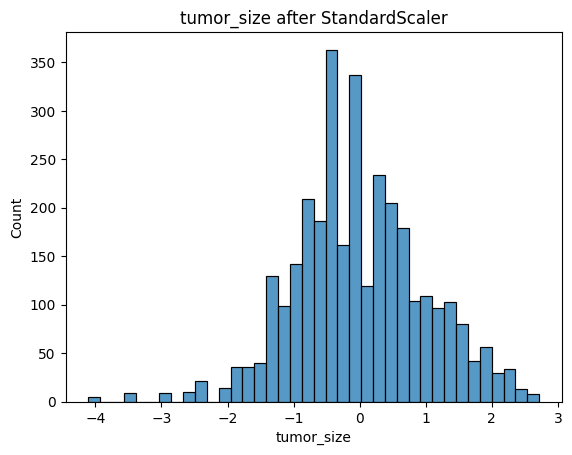

In [33]:
sns.histplot(x_train['tumor_size'])
plt.title('tumor_size after StandardScaler')
plt.show()

In [34]:
x_train['regional_node_examined'] = np.log1p(x_train['regional_node_examined'])
x_test['regional_node_examined'] = np.log1p(x_test['regional_node_examined'])

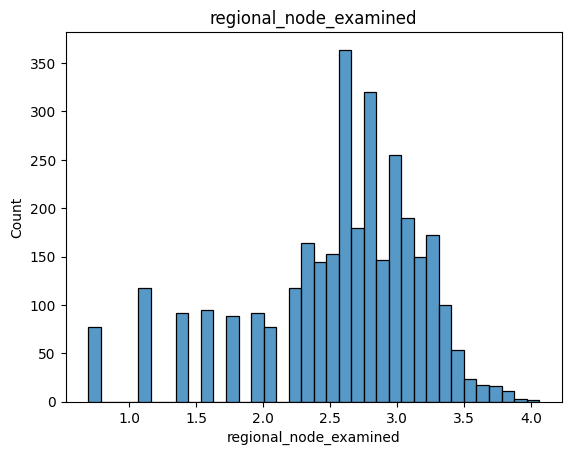

In [35]:
sns.histplot(x='regional_node_examined',data=x_train)
plt.title('regional_node_examined')
plt.show()

In [36]:
scaler=StandardScaler()
x_train['tumor_size_standard'] = scaler.fit_transform(x_train[['tumor_size']])
x_test['tumor_size_standard'] = scaler.transform(x_test[['tumor_size']])

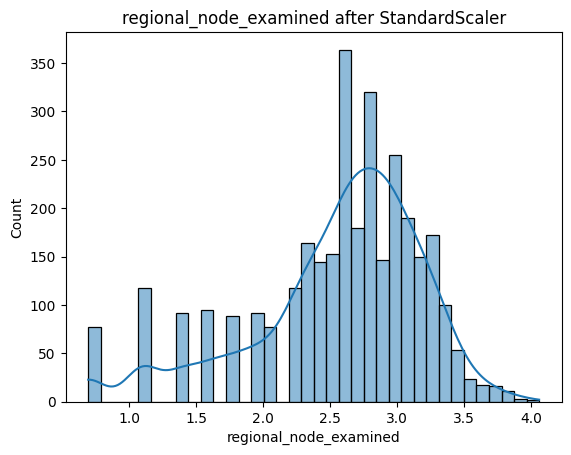

In [37]:
sns.histplot(x='regional_node_examined',data=x_train,kde=True)
plt.title('regional_node_examined after StandardScaler')
plt.show()

In [38]:
x_train['reginol_node_positive'] = np.log1p(x_train['reginol_node_positive'])
x_test['reginol_node_positive'] = np.log1p(x_test['reginol_node_positive'])

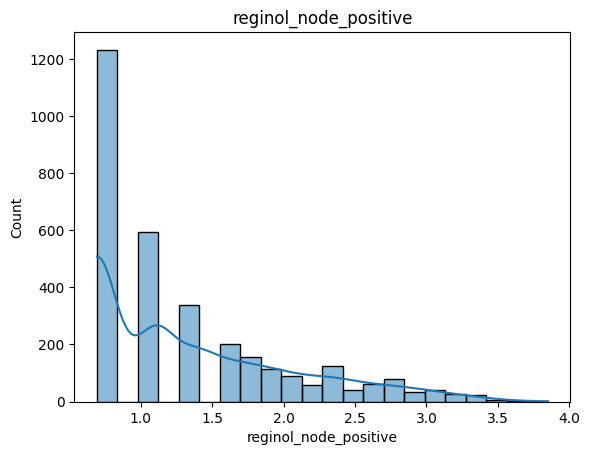

In [39]:
sns.histplot(x_train['reginol_node_positive'],kde=True)
plt.title('reginol_node_positive')
plt.show()

In [40]:
from sklearn.preprocessing import RobustScaler
scaler = RobustScaler()
x_train['reginol_node_positive'] = scaler.fit_transform(x_train[['reginol_node_positive']])
x_test['reginol_node_positive'] = scaler.transform(x_test[['reginol_node_positive']])

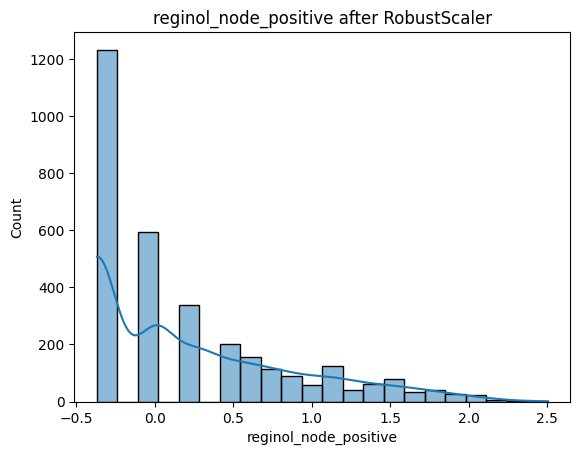

In [41]:
sns.histplot(x_train['reginol_node_positive'], kde=True)
plt.title('reginol_node_positive after RobustScaler')
plt.show()

## Encoding

In [42]:
x_train.columns

Index(['age', 'race', 'marital_status', 't_stage', 'n_stage', '6th_stage',
       'differentiate', 'grade', 'a_stage', 'tumor_size', 'estrogen_status',
       'progesterone_status', 'regional_node_examined',
       'reginol_node_positive', 'survival_months', 'tumor_size_standard'],
      dtype='object')

In [43]:
x_train.columns = x_train.columns.str.strip().str.lower().str.replace(' ','_')
x_test.columns  = x_test.columns.str.strip().str.lower().str.replace(' ','_')


## ordinal Encoding 

In [44]:
t_stage_map = {'T1': 1, 'T2': 2, 'T3': 3, 'T4': 4}
x_train['t_stage'] = x_train['t_stage'].map(t_stage_map)
x_test['t_stage']  = x_test['t_stage'].map(t_stage_map)

In [45]:
x_train['t_stage'].head()

479     2
3693    2
2399    2
1561    2
2684    3
Name: t_stage, dtype: int64

In [46]:
x_train['t_stage'].isna().sum(), x_test['t_stage'].isna().sum()


(np.int64(0), np.int64(0))

In [47]:
n_stage_map = {'N1': 1, 'N2': 2, 'N3': 3}
x_train['n_stage']=x_train['n_stage'].map(n_stage_map)
x_test['n_stage']=x_test['n_stage'].map(n_stage_map)

In [48]:
x_train['n_stage'].isna().sum(), x_test['n_stage'].isna().sum()


(np.int64(0), np.int64(0))

In [49]:
sixth_stage_map = {
    'IIA': 1,
    'IIB': 2,
    'IIIA': 3,
    'IIIB': 4,
    'IIIC': 5
}
x_train['6th_stage'] = x_train['6th_stage'].map(sixth_stage_map)
x_test['6th_stage']  = x_test['6th_stage'].map(sixth_stage_map)

In [50]:
x_train['6th_stage'].isna().sum(),x_test['6th_stage'].isna().sum()

(np.int64(0), np.int64(0))

In [51]:
differentiate_map = {
    'Undifferentiated': 1,
    'Poorly differentiated': 2,
    'Moderately differentiated': 3,
    'Well differentiated': 4
}

x_train['differentiate'] = x_train['differentiate'].map(differentiate_map)
x_test['differentiate']  = x_test['differentiate'].map(differentiate_map)

In [52]:
x_train['differentiate'].isna().sum(),x_test['differentiate'].isna().sum()

(np.int64(0), np.int64(0))

In [53]:
grade_map = {
    '1': 1,
    '2': 2,
    '3': 3,
    ' anaplastic; Grade IV': 4
}

x_train['grade'] = x_train['grade'].map(grade_map)
x_test['grade']  = x_test['grade'].map(grade_map)


In [54]:
x_train['grade'].isna().sum(),x_test['grade'].isna().sum()

(np.int64(0), np.int64(0))

## OHE

In [55]:
from sklearn.preprocessing import OneHotEncoder
one_hot_cols = ['race', 'marital_status']
ohe=OneHotEncoder(drop='first',sparse_output=False)
ohe_train_arr=ohe.fit_transform(x_train[one_hot_cols])
ohe_train_df=pd.DataFrame(
    ohe_train_arr,columns=ohe.get_feature_names_out(one_hot_cols),index=x_train.index
)
ohe_test_arr=ohe.transform(x_test[one_hot_cols])
ohe_test_df=pd.DataFrame(ohe_test_arr,columns=ohe.get_feature_names_out(one_hot_cols),
                        index=x_test.index)
x_train = pd.concat([x_train.drop(columns=one_hot_cols), ohe_train_df], axis=1)
x_test  = pd.concat([x_test.drop(columns=one_hot_cols), ohe_test_df], axis=1)

## Binary columns

In [56]:
# a_stage
# 2
# ['Regional' 'Distant']

#  ---------------------------------------------------------------------------------------------------- 

# estrogen_status
# 2
# ['Positive' 'Negative']

#  ---------------------------------------------------------------------------------------------------- 

# progesterone_status
# 2
# ['Positive' 'Negative']

#  ---------------------------------------------------------------------------------------------------- 

# status
# 2
# ['Alive' 'Dead']

IndentationError: unexpected indent (688844462.py, line 5)

In [57]:
# a_stage
a_stage_map={'Regional':0,'Distant':1}
x_train['a_stage']=x_train['a_stage'].map(a_stage_map)
x_test['a_stage']=x_test['a_stage'].map(a_stage_map)


In [58]:
# estrogen_status
hormone_map={'Negative':0,'Positive':1}
x_train['estrogen_status']=x_train['estrogen_status'].map(hormone_map)
x_test['estrogen_status']=x_test['estrogen_status'].map(hormone_map)

In [59]:
# progesterone_status
x_train['progesterone_status']=x_train['progesterone_status'].map(hormone_map)
x_test['progesterone_status']=x_test['progesterone_status'].map(hormone_map)

In [60]:
x_train

,age,t_stage,n_stage,6th_stage,differentiate,grade,a_stage,tumor_size,estrogen_status,progesterone_status,regional_node_examined,reginol_node_positive,survival_months,tumor_size_standard,race_Other,race_White,marital_status_Married,marital_status_Separated,marital_status_Single,marital_status_Widowed
479,57,2,2,3,4,1,0,-0.263850,1,1,2.890372,0.771244,66,-0.263850,1.0,0.0,1.0,0.0,0.0,0.0
3693,42,2,2,3,3,2,0,0.734376,1,1,2.484907,0.464974,107,0.734376,0.0,1.0,1.0,0.0,0.0,0.0
2399,63,2,1,2,4,1,0,0.525836,1,1,2.639057,-0.369070,102,0.525836,0.0,1.0,0.0,0.0,1.0,0.0
1561,42,2,1,2,2,3,0,0.734376,1,1,3.218876,0.000000,56,0.734376,1.0,0.0,0.0,0.0,0.0,0.0
2684,49,3,1,3,3,2,0,1.765644,1,1,2.708050,-0.369070,71,1.765644,0.0,1.0,0.0,0.0,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2363,56,2,2,3,3,2,0,1.084345,1,1,3.135494,0.630930,74,1.084345,0.0,1.0,1.0,0.0,0.0,0.0
2577,51,2,1,2,4,1,0,0.525836,1,1,2.772589,0.000000,56,0.525836,0.0,1.0,1.0,0.0,0.0,0.0
2608,65,1,2,3,3,2,0,-0.774490,1,0,2.484907,0.771244,100,-0.774490,1.0,0.0,1.0,0.0,0.0,0.0
1974,67,2,1,2,3,2,0,0.734376,1,1,2.890372,0.261860,79,0.734376,0.0,1.0,0.0,0.0,1.0,0.0


In [61]:
x_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 3218 entries, 479 to 3889
Data columns (total 20 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   age                       3218 non-null   int64  
 1   t_stage                   3218 non-null   int64  
 2   n_stage                   3218 non-null   int64  
 3   6th_stage                 3218 non-null   int64  
 4   differentiate             3218 non-null   int64  
 5   grade                     3218 non-null   int64  
 6   a_stage                   3218 non-null   int64  
 7   tumor_size                3218 non-null   float64
 8   estrogen_status           3218 non-null   int64  
 9   progesterone_status       3218 non-null   int64  
 10  regional_node_examined    3218 non-null   float64
 11  reginol_node_positive     3218 non-null   float64
 12  survival_months           3218 non-null   int64  
 13  tumor_size_standard       3218 non-null   float64
 14  race_Other 

In [62]:
x_train=x_train.drop(columns=['survival_months','tumor_size_standard'])
x_test=x_test.drop(columns=['survival_months','tumor_size_standard'])


In [63]:
x_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 3218 entries, 479 to 3889
Data columns (total 18 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   age                       3218 non-null   int64  
 1   t_stage                   3218 non-null   int64  
 2   n_stage                   3218 non-null   int64  
 3   6th_stage                 3218 non-null   int64  
 4   differentiate             3218 non-null   int64  
 5   grade                     3218 non-null   int64  
 6   a_stage                   3218 non-null   int64  
 7   tumor_size                3218 non-null   float64
 8   estrogen_status           3218 non-null   int64  
 9   progesterone_status       3218 non-null   int64  
 10  regional_node_examined    3218 non-null   float64
 11  reginol_node_positive     3218 non-null   float64
 12  race_Other                3218 non-null   float64
 13  race_White                3218 non-null   float64
 14  marital_sta

In [64]:
y_train.info()

<class 'pandas.core.series.Series'>
Index: 3218 entries, 479 to 3889
Series name: status
Non-Null Count  Dtype
--------------  -----
3218 non-null   int64
dtypes: int64(1)
memory usage: 50.3 KB


## unbalanced data

In [ ]:
y_train.value_counts()

In [71]:
from imblearn.over_sampling import SMOTE
smote=SMOTE(random_state=42)
x_train, y_train=smote.fit_resample(x_train,y_train)

In [76]:
y_train.value_counts()

status
0    2725
1    2725
Name: count, dtype: int64

## modeling 

In [97]:
from xgboost import XGBClassifier

xgb = XGBClassifier(
    n_estimators=400,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight= (len(y_train[y_train==0]) / len(y_train[y_train==1])),
    eval_metric='logloss',
    random_state=42
)

xgb.fit(x_train, y_train)


,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.8
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,'logloss'


In [99]:
y_pred=xgb.predict(x_test)
y_pred

array([0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1,
       0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1,
       0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,

In [100]:
print(classification_report(y_test, y_pred))


              precision    recall  f1-score   support

           0       0.87      0.95      0.91       682
           1       0.44      0.23      0.30       123

    accuracy                           0.84       805
   macro avg       0.66      0.59      0.60       805
weighted avg       0.81      0.84      0.82       805



In [103]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=600,
    max_depth=8,
    min_samples_split=10,
    min_samples_leaf=5,
    class_weight='balanced',
    random_state=42
)

rf.fit(x_train, y_train)

y_pred = rf.predict(x_test)
print(classification_report(y_test, y_pred))


              precision    recall  f1-score   support

           0       0.89      0.89      0.89       682
           1       0.39      0.38      0.39       123

    accuracy                           0.81       805
   macro avg       0.64      0.64      0.64       805
weighted avg       0.81      0.81      0.81       805

